# INTEX: Actionable EDA + Correlations (Updated)

Goal: surface insights the nonprofit owner can **act on**, especially:
- Whether certain **safehouses / regions** have better outcomes
- Which operational drivers (visits, sessions, incident rates, occupancy, staffing, partner coverage) are associated with better outcomes
- How **donations (and allocations)** relate to program areas and downstream outcomes
- How resident **education + health trajectories** relate to incidents and case progress

Primary outcome signals in this dataset:
- **Safehouse-month**: `safehouse_monthly_metrics.avg_education_progress`, `avg_health_score`, `incident_count`
- **Resident-month**: `education_records.progress_percent`, `attendance_rate`; `health_wellbeing_records.general_health_score` (+ sub-scores)
- **Funding**: `donations` and `donation_allocations` (by safehouse + program_area + time)

We’ll analyze at safehouse-month level first, then use resident-month tables for deeper progression analysis and donor→allocation→outcome linkage.

In [31]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd

# Make matplotlib usable on systems where the default cache dir isn't writable
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplcache"))

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 160)

DATA_DIR = Path.cwd()  # assumes notebook is opened from the folder with the CSVs
DATA_DIR

PosixPath('/Users/masonzarges/Desktop/INTEX Data')

In [32]:
# Load tables used in this notebook
safehouses = pd.read_csv(DATA_DIR / "safehouses.csv")
metrics = pd.read_csv(DATA_DIR / "safehouse_monthly_metrics.csv")

# Case management domain
residents = pd.read_csv(DATA_DIR / "residents.csv")
incident_reports = pd.read_csv(DATA_DIR / "incident_reports.csv")
home_visitations = pd.read_csv(DATA_DIR / "home_visitations.csv")
process_recordings = pd.read_csv(DATA_DIR / "process_recordings.csv")
intervention_plans = pd.read_csv(DATA_DIR / "intervention_plans.csv")

# Resident progression domain
education_records = pd.read_csv(DATA_DIR / "education_records.csv")
health_records = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv")

# Donor domain
supporters = pd.read_csv(DATA_DIR / "supporters.csv")
donations = pd.read_csv(DATA_DIR / "donations.csv")
donation_allocations = pd.read_csv(DATA_DIR / "donation_allocations.csv")

# Outreach domain
social_media_posts = pd.read_csv(DATA_DIR / "social_media_posts.csv")
public_impact_snapshots = pd.read_csv(DATA_DIR / "public_impact_snapshots.csv")

# Partner domain
partners = pd.read_csv(DATA_DIR / "partners.csv")
partner_assignments = pd.read_csv(DATA_DIR / "partner_assignments.csv")

# In-kind
in_kind_items = pd.read_csv(DATA_DIR / "in_kind_donation_items.csv")

# Dates
for c in ["open_date"]:
    if c in safehouses.columns:
        safehouses[c] = pd.to_datetime(safehouses[c], errors="coerce")

for c in ["month_start", "month_end"]:
    metrics[c] = pd.to_datetime(metrics[c], errors="coerce")

for c in ["date_of_birth", "date_of_admission", "date_enrolled", "date_closed", "created_at"]:
    if c in residents.columns:
        residents[c] = pd.to_datetime(residents[c], errors="coerce")

for c in ["incident_date"]:
    if c in incident_reports.columns:
        incident_reports[c] = pd.to_datetime(incident_reports[c], errors="coerce")

for c in ["visit_date"]:
    if c in home_visitations.columns:
        home_visitations[c] = pd.to_datetime(home_visitations[c], errors="coerce")

for c in ["session_date"]:
    if c in process_recordings.columns:
        process_recordings[c] = pd.to_datetime(process_recordings[c], errors="coerce")

for c in ["target_date", "case_conference_date", "created_at", "updated_at"]:
    if c in intervention_plans.columns:
        intervention_plans[c] = pd.to_datetime(intervention_plans[c], errors="coerce")

for c in ["record_date"]:
    if c in education_records.columns:
        education_records[c] = pd.to_datetime(education_records[c], errors="coerce")

for c in ["record_date"]:
    if c in health_records.columns:
        health_records[c] = pd.to_datetime(health_records[c], errors="coerce")

for c in ["donation_date"]:
    if c in donations.columns:
        donations[c] = pd.to_datetime(donations[c], errors="coerce")

for c in ["allocation_date"]:
    if c in donation_allocations.columns:
        donation_allocations[c] = pd.to_datetime(donation_allocations[c], errors="coerce")

for c in ["created_at"]:
    if c in social_media_posts.columns:
        social_media_posts[c] = pd.to_datetime(social_media_posts[c], errors="coerce")

for c in ["snapshot_date", "published_at"]:
    if c in public_impact_snapshots.columns:
        public_impact_snapshots[c] = pd.to_datetime(public_impact_snapshots[c], errors="coerce")

safehouses.head(), metrics.head()

(   safehouse_id safehouse_code                    name    region         city       province      country  open_date  status  capacity_girls  capacity_staff  \
 0             1           SH01  Lighthouse Safehouse 1     Luzon  Quezon City   Metro Manila  Philippines 2022-01-01  Active               8               4   
 1             2           SH02  Lighthouse Safehouse 2   Visayas    Cebu City           Cebu  Philippines 2022-02-15  Active              10               5   
 2             3           SH03  Lighthouse Safehouse 3  Mindanao   Davao City  Davao del Sur  Philippines 2022-04-01  Active               9               4   
 3             4           SH04  Lighthouse Safehouse 4   Visayas  Iloilo City         Iloilo  Philippines 2022-05-16  Active              12               4   
 4             5           SH05  Lighthouse Safehouse 5     Luzon  Baguio City        Benguet  Philippines 2022-06-30  Active              11               4   
 
    current_occupancy  notes  
 

## 1) Safehouse-month dataset (core analysis unit)

We combine `safehouse_monthly_metrics` with safehouse attributes and add a few derived operational measures:
- **Occupancy rate** 
- **Incidents per active resident**
- **Visits per active resident**
- **Sessions per active resident**

In [33]:
df = metrics.merge(
    safehouses[[
        "safehouse_id",
        "safehouse_code",
        "name",
        "region",
        "city",
        "capacity_girls",
        "capacity_staff",
        "current_occupancy",
        "status",
    ]],
    on="safehouse_id",
    how="left",
)

# Derived rates
for col in ["active_residents", "capacity_girls", "process_recording_count", "home_visitation_count", "incident_count"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# If active_residents is missing, fall back to safehouse current_occupancy
active = df["active_residents"].fillna(df["current_occupancy"])

df["occupancy_rate"] = df["current_occupancy"] / df["capacity_girls"].replace({0: np.nan})
df["incidents_per_resident"] = df["incident_count"] / active.replace({0: np.nan})
df["visits_per_resident"] = df["home_visitation_count"] / active.replace({0: np.nan})
df["sessions_per_resident"] = df["process_recording_count"] / active.replace({0: np.nan})

# Keep a clean analysis subset
analysis_cols = [
    "safehouse_id",
    "safehouse_code",
    "name",
    "region",
    "month_start",
    "active_residents",
    "avg_education_progress",
    "avg_health_score",
    "incident_count",
    "process_recording_count",
    "home_visitation_count",
    "capacity_girls",
    "capacity_staff",
    "current_occupancy",
    "occupancy_rate",
    "incidents_per_resident",
    "visits_per_resident",
    "sessions_per_resident",
]
df_a = df[[c for c in analysis_cols if c in df.columns]].copy()

df_a.describe(include="all").T.head(30)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
safehouse_id,450.0,NaN,NaN,NaN,5.0,1.0,3.0,5.0,7.0,9.0,2.584863
safehouse_code,450,9,SH01,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,450,9,Lighthouse Safehouse 1,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,450,3,Visayas,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month_start,450,NaN,NaN,NaN,2025-01-15 04:19:11.999999744,2023-01-01 00:00:00,2024-01-01 00:00:00,2025-01-16 12:00:00,2026-02-01 00:00:00,2027-02-01 00:00:00,NaN
active_residents,450.0,NaN,NaN,NaN,6.666667,2.0,6.0,7.0,8.0,10.0,2.162651
avg_education_progress,253.0,NaN,NaN,NaN,78.257194,13.0,68.45,80.4,94.2,100.0,18.786188
avg_health_score,253.0,NaN,NaN,NaN,3.182806,2.42,3.05,3.17,3.32,3.94,0.235917
incident_count,450.0,NaN,NaN,NaN,0.222222,0.0,0.0,0.0,0.0,3.0,0.537622
process_recording_count,450.0,NaN,NaN,NaN,6.264444,0.0,1.0,5.0,10.0,28.0,6.013261


## 2) Do certain safehouses consistently have better outcomes?

We’ll rank safehouses on:
- **Higher** education & health
- **Lower** incidents per resident

Then we’ll look at whether top performers share operational characteristics (visits/sessions per resident, occupancy).

In [34]:
# Aggregate over time per safehouse
agg = df_a.groupby(["safehouse_id", "safehouse_code", "name", "region"], dropna=False).agg(
    months_observed=("month_start", "nunique"),
    edu_mean=("avg_education_progress", "mean"),
    health_mean=("avg_health_score", "mean"),
    incidents_per_res_mean=("incidents_per_resident", "mean"),
    visits_per_res_mean=("visits_per_resident", "mean"),
    sessions_per_res_mean=("sessions_per_resident", "mean"),
    occupancy_rate_mean=("occupancy_rate", "mean"),
).reset_index()

# Composite score (simple + transparent): higher edu/health is better; lower incidents is better.
# Standardize each component so we don't overweight scale differences.
def z(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std(ddof=0)

agg["score"] = z(agg["edu_mean"]) + z(agg["health_mean"]) - z(agg["incidents_per_res_mean"])

agg.sort_values("score", ascending=False).head(10)

,safehouse_id,safehouse_code,name,region,months_observed,edu_mean,health_mean,incidents_per_res_mean,visits_per_res_mean,sessions_per_res_mean,occupancy_rate_mean,score
2,3,SH03,Lighthouse Safehouse 3,Mindanao,50,84.035000,3.391786,0.034286,0.502857,0.857143,1.000000,2.208145
7,8,SH08,Lighthouse Safehouse 8,Visayas,50,83.380968,3.200323,0.016667,0.520000,0.746667,0.777778,2.206118
5,6,SH06,Lighthouse Safehouse 6,Mindanao,50,84.997333,3.209667,0.032000,0.428000,0.876000,0.750000,1.601061
1,2,SH02,Lighthouse Safehouse 2,Visayas,50,78.071724,3.206897,0.020000,0.345000,0.647500,0.800000,1.279791
4,5,SH05,Lighthouse Safehouse 5,Luzon,50,84.339200,3.208000,0.036667,0.530000,1.250000,0.818182,1.229252
0,1,SH01,Lighthouse Safehouse 1,Luzon,50,78.005000,3.262222,0.040000,0.526000,1.018000,1.000000,0.384657
3,4,SH04,Lighthouse Safehouse 4,Visayas,50,72.312759,3.234483,0.042500,0.437500,1.202500,1.000000,-0.714272
6,7,SH07,Lighthouse Safehouse 7,Visayas,50,68.283333,3.036000,0.027500,0.300000,0.840000,1.000000,-1.387979
8,9,SH09,Lighthouse Safehouse 9,Mindanao,50,65.670000,2.617333,0.080000,0.430000,1.160000,1.000000,-6.806774


In [35]:
# Compare top vs bottom performers on operational drivers
agg2 = agg.dropna(subset=["score"]).copy()
q_hi = agg2["score"].quantile(0.75)
q_lo = agg2["score"].quantile(0.25)
agg2["tier"] = np.where(agg2["score"] >= q_hi, "Top quartile", np.where(agg2["score"] <= q_lo, "Bottom quartile", "Middle"))

compare_cols = ["edu_mean", "health_mean", "incidents_per_res_mean", "visits_per_res_mean", "sessions_per_res_mean", "occupancy_rate_mean"]
summary = agg2.groupby("tier")[compare_cols].mean().sort_index()
summary

,edu_mean,health_mean,incidents_per_res_mean,visits_per_res_mean,sessions_per_res_mean,occupancy_rate_mean
tier,,,,,,
Bottom quartile,68.755364,2.962605,0.050000,0.389167,1.067500,1.000000
Middle,80.138641,3.225706,0.032222,0.467000,0.971833,0.872727
Top quartile,84.137767,3.267258,0.027651,0.483619,0.826603,0.842593


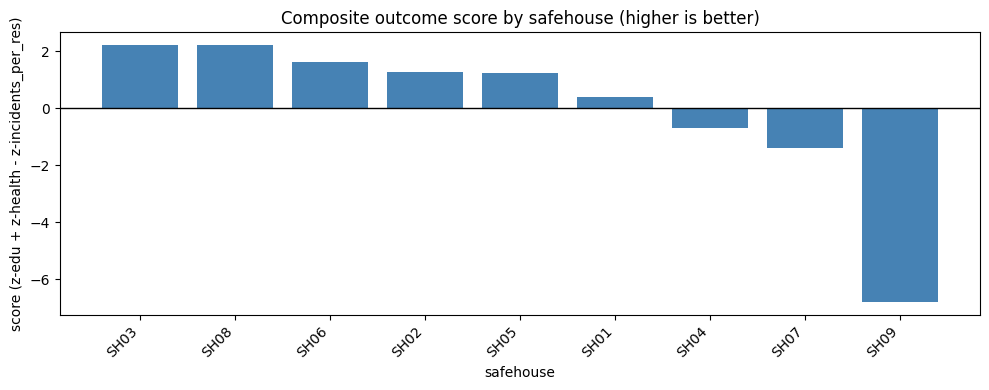

In [36]:
# Simple visualization: score by safehouse
plot_df = agg2.sort_values("score", ascending=False).copy()
plt.figure(figsize=(10, 4))
plt.bar(plot_df["safehouse_code"].astype(str), plot_df["score"], color="steelblue")
plt.axhline(0, color="black", linewidth=1)
plt.title("Composite outcome score by safehouse (higher is better)")
plt.ylabel("score (z-edu + z-health - z-incidents_per_res)")
plt.xlabel("safehouse")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3) Correlations: what is associated with better outcomes?

We’ll look at correlations at the safehouse-month level:
- Education progress vs incidents, visits, sessions, occupancy
- Health score vs incidents, visits, sessions, occupancy

Notes:
- Correlation ≠ causation.
- Still useful for **prioritizing experiments** (e.g., increase home visit frequency and see if incident rates drop).

In [37]:
corr_cols = [
    "avg_education_progress",
    "avg_health_score",
    "incidents_per_resident",
    "visits_per_resident",
    "sessions_per_resident",
    "occupancy_rate",
    "active_residents",
]

corr_df = df_a[corr_cols].copy()

# numeric conversion
for c in corr_df.columns:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce")

corr = corr_df.corr(numeric_only=True)
corr

,avg_education_progress,avg_health_score,incidents_per_resident,visits_per_resident,sessions_per_resident,occupancy_rate,active_residents
avg_education_progress,1.000000,0.388095,-0.069698,0.092531,0.038278,-0.218581,-0.029768
avg_health_score,0.388095,1.000000,-0.152869,-0.023649,-0.071778,-0.089238,0.395794
incidents_per_resident,-0.069698,-0.152869,1.000000,0.267078,0.397335,0.083992,-0.092598
visits_per_resident,0.092531,-0.023649,0.267078,1.000000,0.644903,-0.015558,-0.006624
sessions_per_resident,0.038278,-0.071778,0.397335,0.644903,1.000000,0.088470,-0.055686
occupancy_rate,-0.218581,-0.089238,0.083992,-0.015558,0.088470,1.000000,0.200752
active_residents,-0.029768,0.395794,-0.092598,-0.006624,-0.055686,0.200752,1.000000


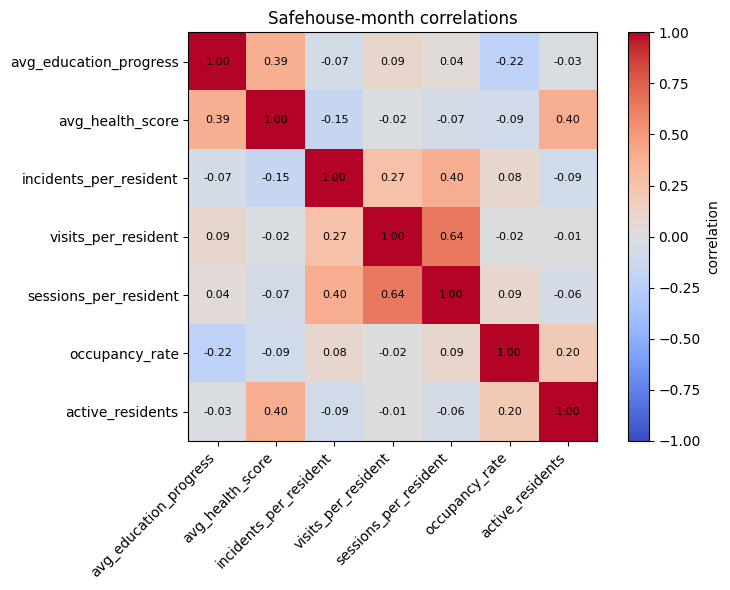

In [38]:
# Visualize correlations as a heatmap (matplotlib only)
M = corr.values
labels = corr.columns.tolist()

plt.figure(figsize=(8, 6))
plt.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

# annotate
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = M[i, j]
        if np.isfinite(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.title("Safehouse-month correlations")
plt.tight_layout()
plt.show()

## 4) Region comparison

If one region performs better, leadership can dig into what’s different operationally (partner coverage, staffing, occupancy, local resources).

In [39]:
region_month = df_a.groupby(["region", "month_start"], dropna=False).agg(
    edu_mean=("avg_education_progress", "mean"),
    health_mean=("avg_health_score", "mean"),
    incidents_per_res_mean=("incidents_per_resident", "mean"),
    visits_per_res_mean=("visits_per_resident", "mean"),
    sessions_per_res_mean=("sessions_per_resident", "mean"),
).reset_index()

region_summary = region_month.groupby("region").mean(numeric_only=True).sort_values("edu_mean", ascending=False)
region_summary

,edu_mean,health_mean,incidents_per_res_mean,visits_per_res_mean,sessions_per_res_mean
region,,,,,
Mindanao,82.139141,3.176717,0.048762,0.453619,0.964381
Luzon,82.074189,3.289865,0.038333,0.528000,1.134000
Visayas,74.572338,3.170255,0.026667,0.400625,0.859167


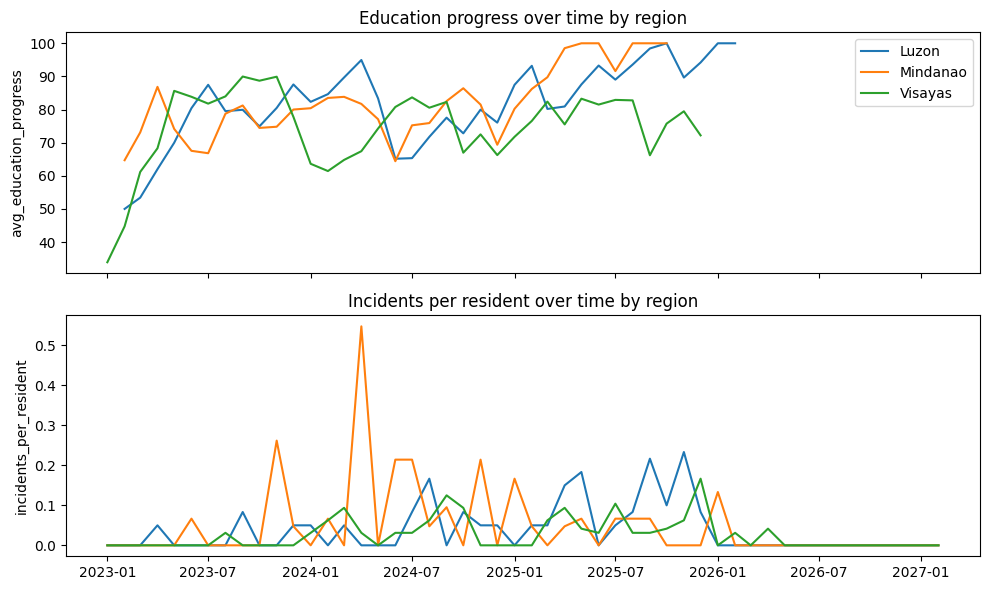

In [40]:
# Plot region trends over time (education + incidents per resident)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for region, g in region_month.sort_values("month_start").groupby("region"):
    axes[0].plot(g["month_start"], g["edu_mean"], label=str(region))
axes[0].set_title("Education progress over time by region")
axes[0].set_ylabel("avg_education_progress")
axes[0].legend()

for region, g in region_month.sort_values("month_start").groupby("region"):
    axes[1].plot(g["month_start"], g["incidents_per_res_mean"], label=str(region))
axes[1].set_title("Incidents per resident over time by region")
axes[1].set_ylabel("incidents_per_resident")

plt.tight_layout()
plt.show()

## 5) Resident-level sanity checks (optional)

This section answers operational questions like:
- Do some safehouses have higher shares of **High/Critical** risk residents?
- Are some safehouses closing cases faster (shorter length-of-stay) while maintaining outcomes?

Important: resident case mix differs by safehouse; interpret these as **starting points**, not “final grades”.

In [41]:
# Risk level distribution by safehouse
res = residents.copy()

# normalize some columns
for c in ["safehouse_id"]:
    res[c] = pd.to_numeric(res[c], errors="coerce")

# join safehouse labels
res = res.merge(safehouses[["safehouse_id", "safehouse_code", "region"]], on="safehouse_id", how="left")

risk = (
    res.groupby(["safehouse_code", "region", "current_risk_level"], dropna=False)["resident_id"]
    .count()
    .rename("n")
    .reset_index()
)

pivot = risk.pivot_table(index=["safehouse_code", "region"], columns="current_risk_level", values="n", fill_value=0)
(pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1).sort_index()

,current_risk_level,Critical,High,Low,Medium
safehouse_code,region,,,,
SH01,Luzon,0.0,10.0,60.0,30.0
SH02,Visayas,0.0,0.0,87.5,12.5
SH03,Mindanao,0.0,14.3,28.6,57.1
SH04,Visayas,0.0,25.0,62.5,12.5
SH05,Luzon,16.7,0.0,33.3,50.0
SH06,Mindanao,0.0,0.0,60.0,40.0
SH07,Visayas,0.0,0.0,62.5,37.5
SH08,Visayas,0.0,0.0,66.7,33.3
SH09,Mindanao,0.0,50.0,0.0,50.0


In [42]:
# Length of stay and closure rates by safehouse
res2 = residents.copy()
res2 = res2.merge(safehouses[["safehouse_id", "safehouse_code", "region"]], on="safehouse_id", how="left")

# length_of_stay is a string like "2 Years 4 months"; parse into approx days

def parse_length_of_stay_to_days(s: object) -> float:
    if pd.isna(s):
        return np.nan
    txt = str(s).lower()
    years = 0.0
    months = 0.0
    # very tolerant parsing
    for part in txt.replace("years", "year").replace("months", "month").split():
        pass
    try:
        if "year" in txt:
            years = float(txt.split("year")[0].strip().split()[-1])
    except Exception:
        years = np.nan
    try:
        if "month" in txt:
            months = float(txt.split("month")[0].strip().split()[-1])
    except Exception:
        months = np.nan
    if np.isnan(years) and np.isnan(months):
        return np.nan
    years = 0.0 if np.isnan(years) else years
    months = 0.0 if np.isnan(months) else months
    return years * 365.25 + months * 30.4

res2["los_days"] = res2["length_of_stay"].apply(parse_length_of_stay_to_days)
res2["is_closed"] = (res2["case_status"].astype(str).str.lower() == "closed")

los_summary = res2.groupby(["safehouse_code", "region"], dropna=False).agg(
    residents_n=("resident_id", "count"),
    closed_rate=("is_closed", "mean"),
    los_days_median=("los_days", "median"),
    los_days_mean=("los_days", "mean"),
)

(los_summary.sort_values(["closed_rate", "los_days_median"], ascending=[False, True])
 .assign(closed_rate=lambda d: (d["closed_rate"] * 100).round(1)))

,,residents_n,closed_rate,los_days_median,los_days_mean
safehouse_code,region,,,,
SH02,Visayas,8,50.0,456.450,444.881250
SH09,Mindanao,2,50.0,501.825,501.825000
SH08,Visayas,6,50.0,623.650,633.858333
SH03,Mindanao,7,42.9,456.450,512.842857
SH01,Luzon,10,40.0,578.050,593.295000
SH04,Visayas,8,25.0,593.475,604.818750
SH05,Luzon,6,16.7,608.450,679.533333
SH07,Visayas,8,12.5,410.850,524.850000
SH06,Mindanao,5,0.0,547.650,559.900000


## 6) Actionable recommendations (template)

After running the notebook, fill in this section based on the outputs above.

- **Operational levers to test** (based on correlations):
  - If `visits_per_resident` is negatively correlated with `incidents_per_resident`, consider a 60–90 day pilot to increase visit cadence for high-risk cases.
  - If `sessions_per_resident` correlates with improved `avg_health_score`, standardize minimum counseling session frequency.

- **Safehouse replication**:
  - Pick the top-performing safehouse by `score`, review their staffing patterns, partner assignments, and routines, then replicate the top 2–3 practices in a lower-performing home.

- **Capacity & occupancy**:
  - If `occupancy_rate` is associated with worse outcomes, consider staffing increases or admissions pacing when occupancy is high.

- **Data improvements to unlock stronger decisions**:
  - Add/confirm monthly resident-level education/health records (mentioned in the dictionary) so we can do case-mix-adjusted comparisons (apples-to-apples).

## 7) Relationship mining (from the W26 case brief)

The W26 brief suggests three major “relationship” areas worth exploring:

- **Safehouse operations → resident outcomes** (already covered above)
- **Case management activity → risk/progression** (sessions, visits, interventions, incidents)
- **Social media → donation referrals/value** (what to post, where, when)

This section computes many candidate relationships and stores the strongest ones to summarize at the end.

In [43]:
from dataclasses import dataclass
from typing import Any


@dataclass
class Finding:
    domain: str
    relationship: str
    metric: str
    strength: float  # comparable scalar (e.g., correlation or standardized gap)
    notes: str


findings: list[Finding] = []


def add_corr(domain: str, relationship: str, x: pd.Series, y: pd.Series, notes: str = "") -> None:
    s = pd.concat([pd.to_numeric(x, errors="coerce"), pd.to_numeric(y, errors="coerce")], axis=1).dropna()
    if s.shape[0] < 10:
        return
    r = float(s.iloc[:, 0].corr(s.iloc[:, 1]))
    if np.isfinite(r):
        findings.append(Finding(domain, relationship, metric="pearson_r", strength=r, notes=notes))


def add_group_gap(domain: str, relationship: str, y: pd.Series, group: pd.Series, notes: str = "") -> None:
    # standardized range of group means: (max(mean)-min(mean))/std
    df_tmp = pd.DataFrame({"y": pd.to_numeric(y, errors="coerce"), "g": group.astype(str)})
    df_tmp = df_tmp.dropna(subset=["y"]).copy()
    if df_tmp["g"].nunique() < 2 or df_tmp.shape[0] < 20:
        return
    means = df_tmp.groupby("g")["y"].mean()
    sd = df_tmp["y"].std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        return
    gap = float((means.max() - means.min()) / sd)
    if np.isfinite(gap):
        findings.append(Finding(domain, relationship, metric="std_range_gap", strength=gap, notes=notes))

In [44]:
# 7a) Case management activity -> resident risk change / outcomes (resident-level)

res = residents.copy()
res = res.merge(safehouses[["safehouse_id", "safehouse_code", "region"]], on="safehouse_id", how="left")

# define a simple, actionable signal: risk_improved (current lower than initial)
risk_order = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
res["initial_risk_num"] = res["initial_risk_level"].map(risk_order)
res["current_risk_num"] = res["current_risk_level"].map(risk_order)
res["risk_delta"] = res["current_risk_num"] - res["initial_risk_num"]  # negative = improvement

# aggregate activities per resident
sess = process_recordings.groupby("resident_id").agg(
    sessions_n=("recording_id", "count"),
    session_minutes_sum=("session_duration_minutes", "sum"),
    concerns_n=("concerns_flagged", lambda s: s.fillna(False).astype(bool).sum()),
    referrals_n=("referral_made", lambda s: s.fillna(False).astype(bool).sum()),
).reset_index()

vis = home_visitations.groupby("resident_id").agg(
    visits_n=("visitation_id", "count"),
    safety_concerns_n=("safety_concerns_noted", lambda s: s.fillna(False).astype(bool).sum()),
    followups_n=("follow_up_needed", lambda s: s.fillna(False).astype(bool).sum()),
).reset_index()

inc = incident_reports.groupby("resident_id").agg(
    incidents_n=("incident_id", "count"),
    high_sev_n=("severity", lambda s: (s.astype(str).str.lower() == "high").sum()),
    unresolved_n=("resolved", lambda s: (~s.fillna(False).astype(bool)).sum()),
).reset_index()

plans = intervention_plans.groupby("resident_id").agg(
    plans_n=("plan_id", "count"),
    plan_categories_n=("plan_category", pd.Series.nunique),
    achieved_n=("status", lambda s: (s.astype(str).str.lower() == "achieved").sum()),
).reset_index()

res_m = res.merge(sess, on="resident_id", how="left").merge(vis, on="resident_id", how="left").merge(inc, on="resident_id", how="left").merge(plans, on="resident_id", how="left")

# correlations with risk_delta (note: correlation, not causal)
for col in ["sessions_n", "session_minutes_sum", "visits_n", "incidents_n", "high_sev_n", "plans_n", "achieved_n"]:
    add_corr(
        domain="case_management",
        relationship=f"{col} vs risk_delta (negative means improvement)",
        x=res_m[col],
        y=res_m["risk_delta"],
        notes="Resident-level aggregate; interpret with caution due to case severity confounding.",
    )

# group gaps: safehouse differences in risk_delta and closure rate
res_m["is_closed"] = res_m["case_status"].astype(str).str.lower().eq("closed")
add_group_gap("case_management", "mean risk_delta by safehouse", res_m["risk_delta"], res_m["safehouse_code"], "Some safehouses may have tougher case mix.")
add_group_gap("case_management", "closed rate by safehouse", res_m["is_closed"].astype(int), res_m["safehouse_code"], "Closure rate differences can reflect reintegration pipelines and policy.")

res_m[["resident_id", "safehouse_code", "initial_risk_level", "current_risk_level", "risk_delta", "sessions_n", "visits_n", "incidents_n", "plans_n"]].head()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,resident_id,safehouse_code,initial_risk_level,current_risk_level,risk_delta,sessions_n,visits_n,incidents_n,plans_n
0,1,SH04,Critical,High,-1,106,54.0,4.0,3
1,2,SH03,Medium,Medium,0,51,35.0,NaN,3
2,3,SH01,Medium,Medium,0,53,26.0,2.0,3
3,4,SH02,High,Low,-2,57,9.0,3.0,3
4,5,SH04,Medium,Low,-1,18,11.0,2.0,3


In [45]:
# 7b) Social media -> donation referrals/value (post-level)

sm = social_media_posts.copy()

# A few core relationships leadership will care about
add_corr("outreach", "click_throughs vs donation_referrals", sm.get("click_throughs"), sm.get("donation_referrals"), "If strong: optimize for clicks as a leading indicator.")
add_corr("outreach", "engagement_rate vs donation_referrals", sm.get("engagement_rate"), sm.get("donation_referrals"), "If weak: likes ≠ donations.")
add_corr("outreach", "reach vs estimated_donation_value_php", sm.get("reach"), sm.get("estimated_donation_value_php"), "Scale effect.")
add_corr("outreach", "has_call_to_action vs estimated_donation_value_php", sm.get("has_call_to_action"), sm.get("estimated_donation_value_php"), "CTA presence may matter.")

# Group gaps: which platform/post_type/topic produces higher donation referrals/value on average
if "estimated_donation_value_php" in sm.columns:
    add_group_gap("outreach", "estimated donation value by platform", sm["estimated_donation_value_php"], sm["platform"], "Where should we post? (value)")
    add_group_gap("outreach", "estimated donation value by post_type", sm["estimated_donation_value_php"], sm["post_type"], "What kind of post? (value)")
    add_group_gap("outreach", "estimated donation value by content_topic", sm["estimated_donation_value_php"], sm["content_topic"], "What topic converts? (value)")

if "donation_referrals" in sm.columns:
    add_group_gap("outreach", "donation referrals by platform", sm["donation_referrals"], sm["platform"], "Where should we post? (referrals)")
    add_group_gap("outreach", "donation referrals by post_type", sm["donation_referrals"], sm["post_type"], "What kind of post? (referrals)")
    add_group_gap("outreach", "donation referrals by post_hour", sm["donation_referrals"], sm.get("post_hour"), "When should we post? (hour)")

# Helpful tables for the team
sm_summary = sm.groupby(["platform", "post_type"], dropna=False).agg(
    posts=("post_id", "count"),
    donation_referrals_mean=("donation_referrals", "mean"),
    est_value_mean=("estimated_donation_value_php", "mean"),
    engagement_rate_mean=("engagement_rate", "mean"),
    click_throughs_mean=("click_throughs", "mean"),
).sort_values(["est_value_mean", "donation_referrals_mean"], ascending=False)

sm_summary.head(15)

,,posts,donation_referrals_mean,est_value_mean,engagement_rate_mean,click_throughs_mean
platform,post_type,,,,,
WhatsApp,ImpactStory,34,55.176471,185216.716471,0.107826,47.294118
YouTube,ImpactStory,18,48.888889,171456.014444,0.088194,338.833333
TikTok,ImpactStory,23,48.043478,135595.547826,0.085643,263.434783
LinkedIn,ImpactStory,15,16.600000,131777.450667,0.094360,45.400000
Facebook,ImpactStory,44,37.000000,104928.057500,0.101734,137.659091
Instagram,ImpactStory,37,32.918919,91759.319730,0.090281,97.810811
TikTok,FundraisingAppeal,14,24.000000,75279.506429,0.119371,370.000000
YouTube,FundraisingAppeal,9,36.888889,57281.281111,0.132578,270.333333
TikTok,Campaign,19,12.789474,42454.894211,0.109768,295.736842


In [46]:
# 7c) Partner coverage -> safehouse outcomes (safehouse-level)

pa = partner_assignments.copy()
pa["safehouse_id"] = pd.to_numeric(pa["safehouse_id"], errors="coerce")

partner_cov = pa.dropna(subset=["safehouse_id"]).groupby("safehouse_id").agg(
    partners_n=("partner_id", pd.Series.nunique),
    assignments_n=("assignment_id", "count"),
    program_areas_n=("program_area", pd.Series.nunique),
    primary_assignments_n=("is_primary", lambda s: s.fillna(False).astype(bool).sum()),
).reset_index()

agg_safehouse = agg.merge(partner_cov, on="safehouse_id", how="left")

for col in ["partners_n", "assignments_n", "program_areas_n", "primary_assignments_n"]:
    add_corr("partners", f"{col} vs safehouse composite score", agg_safehouse[col], agg_safehouse["score"], "More coverage might associate with better outcomes (or be targeted to higher-need homes).")

agg_safehouse[["safehouse_code", "score", "partners_n", "program_areas_n", "assignments_n"]].sort_values("score", ascending=False)

,safehouse_code,score,partners_n,program_areas_n,assignments_n
2,SH03,2.208145,5,3,5
7,SH08,2.206118,8,3,8
5,SH06,1.601061,2,2,2
1,SH02,1.279791,4,3,4
4,SH05,1.229252,3,3,3
0,SH01,0.384657,3,3,3
3,SH04,-0.714272,5,3,5
6,SH07,-1.387979,4,4,4
8,SH09,-6.806774,4,3,4


In [47]:
# 7d) In-kind donation items -> signals (limited without donations/allocation tables)
# Still useful: what categories are most common (procurement planning) and whether condition varies by category.

ik = in_kind_items.copy()

cat_counts = ik["item_category"].value_counts(dropna=False).rename("count").to_frame()
cond_by_cat = (
    ik.pivot_table(index="item_category", columns="received_condition", values="quantity", aggfunc="sum", fill_value=0)
    if "received_condition" in ik.columns
    else None
)

cat_counts.head(20), cond_by_cat.head(20) if cond_by_cat is not None else None

(                 count
 item_category         
 Supplies            23
 SchoolMaterials     22
 Medical             20
 Clothing            20
 Food                15
 Hygiene             15
 Furniture           14,
 received_condition  Fair  Good  New
 item_category                      
 Clothing              62    82  203
 Food                  21    57  169
 Furniture              0    77  113
 Hygiene               12     0  138
 Medical               16    57  248
 SchoolMaterials       10    26  305
 Supplies               0    92  255)

## 8) Best relationships summary (auto-ranked)

This prints a ranked list of relationships worth exploring further.

Interpretation guide:
- **pearson_r**: closer to ±1 is stronger linear association.
- **std_range_gap**: larger means bigger differences across groups (platforms, safehouses, post types, etc.).

In [48]:
# Build a clean summary table

findings_df = pd.DataFrame([
    {
        "domain": f.domain,
        "relationship": f.relationship,
        "metric": f.metric,
        "strength": f.strength,
        "abs_strength": abs(f.strength),
        "notes": f.notes,
    }
    for f in findings
])


def recommendation_for(row: pd.Series) -> dict[str, Any]:
    domain = str(row["domain"])
    rel = str(row["relationship"]).lower()
    metric = str(row["metric"])
    s = float(row["strength"])

    rec: dict[str, Any] = {
        "why_it_matters": "",
        "what_to_do": [],
        "how_to_validate_next": [],
        "watch_out_for": [],
    }

    # --- Outreach / social media ---
    if domain == "outreach":
        if "click_throughs" in rel and "donation_referrals" in rel:
            rec["why_it_matters"] = "Clicks look like a leading indicator for donation actions."
            rec["what_to_do"] = [
                "Treat click-throughs as a primary KPI (paired with donation referrals/value).",
                "Standardize CTAs (one clear link + consistent landing page).",
                "Run A/B tests on CTA wording and creative for the top 2–3 post types.",
            ]
            rec["how_to_validate_next"] = [
                "Segment by platform: compute the same correlation per platform.",
                "Check lag: do clicks this day/week predict donations in the next 1–7 days?",
            ]
            rec["watch_out_for"] = [
                "Bots/low-quality clicks on some platforms.",
                "Attribution in this dataset is simulated; confirm your real tracking approach.",
            ]
        elif "engagement_rate" in rel and "donation_referrals" in rel:
            rec["why_it_matters"] = "Engagement may not translate to donations; likes can be vanity metrics."
            rec["what_to_do"] = [
                "Optimize for donation referrals/value first, engagement second.",
                "Use engagement as a diagnostic, not the success metric.",
            ]
            rec["how_to_validate_next"] = [
                "Compare models: predict donation_referrals using engagement_rate + click_throughs + has_call_to_action.",
            ]
            rec["watch_out_for"] = [
                "A platform can have high engagement but low donor conversion.",
            ]
        elif "donation referrals by platform" in rel:
            rec["why_it_matters"] = "Some platforms likely convert far better than others."
            rec["what_to_do"] = [
                "Shift posting effort toward top-converting platforms (keep a small test budget elsewhere).",
                "Match content types to platforms (e.g., ImpactStory on the best platform).",
            ]
            rec["how_to_validate_next"] = [
                "Control for post_type/content_topic: compare platforms within the same post type.",
                "Track cost if boosted: compute ROI = estimated_donation_value_php / boost_budget_php.",
            ]
            rec["watch_out_for"] = [
                "Platform mix may differ by audience; avoid dropping awareness platforms entirely.",
            ]
        elif "estimated donation value" in rel and ("post_type" in rel or "content_topic" in rel):
            rec["why_it_matters"] = "Message strategy can materially change donated value."
            rec["what_to_do"] = [
                "Build a simple content calendar biased toward the highest-value post types/topics.",
                "Reuse winners: adapt top-performing captions/structures across platforms.",
            ]
            rec["how_to_validate_next"] = [
                "Look at distributions, not just means (median + top-decile value).",
                "Check whether CTA presence mediates the effect.",
            ]
            rec["watch_out_for"] = [
                "Means can be skewed by a few viral posts; report medians too.",
            ]

    # --- Case management ---
    if domain == "case_management":
        if "vs risk_delta" in rel:
            rec["why_it_matters"] = "Activity volume is related to risk movement, but severity confounding is likely."
            rec["what_to_do"] = [
                "Use this to design protocols (minimum touchpoints) rather than making causal claims.",
                "Create an 'at risk of falling through cracks' list: low sessions/visits AND worsening risk.",
            ]
            rec["how_to_validate_next"] = [
                "Stratify by initial_risk_level and safehouse; recompute correlations within strata.",
                "Use rates: sessions per month since admission (not raw counts).",
                "Add a time window: last-30-days sessions/visits vs incidents next-30-days.",
            ]
            rec["watch_out_for"] = [
                "More sessions could be a response to higher severity (reverse causality).",
            ]
        elif "closed rate by safehouse" in rel:
            rec["why_it_matters"] = "Large closure-rate differences suggest process/policy differences across homes."
            rec["what_to_do"] = [
                "Audit the top and bottom safehouses: reintegration partners, process steps, bottlenecks.",
                "Standardize checklists for case closure readiness.",
            ]
            rec["how_to_validate_next"] = [
                "Adjust for case mix: compare closure rates within initial_risk_level.",
                "Compare median length-of-stay for closed cases only.",
            ]
            rec["watch_out_for"] = [
                "High closure rates can be good or bad depending on outcome quality.",
            ]

    # --- Partners ---
    if domain == "partners":
        if "vs safehouse composite score" in rel:
            rec["why_it_matters"] = "Partner coverage might be an operational lever (or correlate with need)."
            rec["what_to_do"] = [
                "If positive: replicate partner coverage model from top-performing homes.",
                "Ensure each safehouse has coverage across core program areas (Education, Wellbeing, Operations).",
            ]
            rec["how_to_validate_next"] = [
                "Break down by program_area: does Education coverage align with education progress?",
                "Compare primary vs non-primary assignments.",
            ]
            rec["watch_out_for"] = [
                "Partners may be allocated to struggling homes, masking benefit in raw correlations.",
            ]

    # Fallback if nothing matched
    if not rec["why_it_matters"]:
        rec["why_it_matters"] = "High-signal association worth follow-up."
        rec["what_to_do"] = ["Run a focused follow-up analysis to see if this holds after segmentation."]
        rec["how_to_validate_next"] = ["Slice by safehouse/region/time and re-check stability."]
        rec["watch_out_for"] = ["Correlation ≠ causation."]

    # Add an explicit interpretation line based on sign
    direction = "positive" if s >= 0 else "negative"
    rec["direction_note"] = f"Observed association is {direction} (strength={s:.3f}, metric={metric})."
    return rec


if findings_df.empty:
    print("No findings were recorded (check upstream cells).")
else:
    display(findings_df.sort_values(["abs_strength"], ascending=False).head(30))

    top = findings_df.sort_values(["abs_strength"], ascending=False).head(12)
    print("\n=== Best relationships to explore next (top 12) ===")

    for i, (_, row) in enumerate(top.iterrows(), start=1):
        rec = recommendation_for(row)
        s = float(row["strength"])
        sign = "+" if s >= 0 else ""

        print(f"\n{i}. [{row['domain']}] {row['relationship']}")
        print(f"   Signal: {row['metric']}={sign}{s:.3f}")
        print(f"   Why it matters: {rec['why_it_matters']}")
        print(f"   Interpretation: {rec['direction_note']}")

        print("   Suggestions:")
        for w in rec["what_to_do"]:
            print(f"   - {w}")

        print("   Next validation steps:")
        for v in rec["how_to_validate_next"]:
            print(f"   - {v}")

        if rec.get("watch_out_for"):
            print("   Watch-outs:")
            for c in rec["watch_out_for"]:
                print(f"   - {c}")

,domain,relationship,metric,strength,abs_strength,notes
6,case_management,mean risk_delta by safehouse,std_range_gap,1.204829,1.204829,Some safehouses may have tougher case mix.
16,outreach,donation referrals by post_type,std_range_gap,1.138038,1.138038,What kind of post? (referrals)
7,case_management,closed rate by safehouse,std_range_gap,1.074862,1.074862,Closure rate differences can reflect reintegra...
17,outreach,donation referrals by post_hour,std_range_gap,1.013941,1.013941,When should we post? (hour)
13,outreach,estimated donation value by post_type,std_range_gap,0.914465,0.914465,What kind of post? (value)
15,outreach,donation referrals by platform,std_range_gap,0.602331,0.602331,Where should we post? (referrals)
4,case_management,high_sev_n vs risk_delta (negative means impro...,pearson_r,-0.544459,0.544459,Resident-level aggregate; interpret with cauti...
12,outreach,estimated donation value by platform,std_range_gap,0.517512,0.517512,Where should we post? (value)
10,outreach,reach vs estimated_donation_value_php,pearson_r,0.398011,0.398011,Scale effect.
8,outreach,click_throughs vs donation_referrals,pearson_r,0.385143,0.385143,If strong: optimize for clicks as a leading in...



=== Best relationships to explore next (top 12) ===

1. [case_management] mean risk_delta by safehouse
   Signal: std_range_gap=+1.205
   Why it matters: High-signal association worth follow-up.
   Interpretation: Observed association is positive (strength=1.205, metric=std_range_gap).
   Suggestions:
   - Run a focused follow-up analysis to see if this holds after segmentation.
   Next validation steps:
   - Slice by safehouse/region/time and re-check stability.
   Watch-outs:
   - Correlation ≠ causation.

2. [outreach] donation referrals by post_type
   Signal: std_range_gap=+1.138
   Why it matters: High-signal association worth follow-up.
   Interpretation: Observed association is positive (strength=1.138, metric=std_range_gap).
   Suggestions:
   - Run a focused follow-up analysis to see if this holds after segmentation.
   Next validation steps:
   - Slice by safehouse/region/time and re-check stability.
   Watch-outs:
   - Correlation ≠ causation.

3. [case_management] closed 

## 9) Donations → allocations → outcomes (safehouse-month)

This section links:
- `donation_allocations` → safehouse + program_area + month
- safehouse-month outcomes (`safehouse_monthly_metrics`)

Goal: identify whether higher allocation in key program areas (Education / Wellbeing) is associated with better outcomes (education progress, health score) and/or fewer incidents.

Caveat: this is **correlation**, and allocations may be targeted to higher-need safehouses.

In [ ]:
# Build safehouse-month allocation table

da = donation_allocations.copy()

da["safehouse_id"] = pd.to_numeric(da["safehouse_id"], errors="coerce")
da["amount_allocated"] = pd.to_numeric(da["amount_allocated"], errors="coerce")

da["month_start"] = da["allocation_date"].dt.to_period("M").dt.to_timestamp()

alloc_sm = da.pivot_table(
    index=["safehouse_id", "month_start"],
    columns="program_area",
    values="amount_allocated",
    aggfunc="sum",
    fill_value=0.0,
).reset_index()

# Merge with safehouse_monthly_metrics
d_out = df_a.merge(alloc_sm, on=["safehouse_id", "month_start"], how="left")

# Replace missing allocations with 0
program_cols = [c for c in alloc_sm.columns if c not in {"safehouse_id", "month_start"}]
for c in program_cols:
    d_out[c] = pd.to_numeric(d_out[c], errors="coerce").fillna(0.0)

# Correlate allocations with outcomes
for c in program_cols:
    add_corr("donations", f"alloc {c} vs avg_education_progress", d_out[c], d_out["avg_education_progress"], "safehouse-month")
    add_corr("donations", f"alloc {c} vs avg_health_score", d_out[c], d_out["avg_health_score"], "safehouse-month")
    add_corr("donations", f"alloc {c} vs incidents_per_resident", d_out[c], d_out["incidents_per_resident"], "safehouse-month")

# Quick table: allocations by program area
(d_out.groupby("safehouse_code")[program_cols].sum().sort_index())

## 10) Resident education & health trajectories (resident-month)

This section uses the resident-month tables (`education_records`, `health_wellbeing_records`) to find actionable relationships:
- Are **incidents** associated with subsequent drops in education/health?
- Do **sessions/visits** associate with better month-over-month improvements?

We’ll build resident-month features and compute correlations/gaps, then the global “Best relationships” summary will include these too.

In [ ]:
# Build resident-month table

er = education_records.copy()
hr = health_records.copy()

# Normalize to month start
er["month_start"] = er["record_date"].dt.to_period("M").dt.to_timestamp()
hr["month_start"] = hr["record_date"].dt.to_period("M").dt.to_timestamp()

# Aggregate education/health per resident-month
edu_rm = er.groupby(["resident_id", "month_start"]).agg(
    edu_progress=("progress_percent", "mean"),
    edu_attendance=("attendance_rate", "mean"),
    edu_completed=("completion_status", lambda s: (s.astype(str).str.lower() == "completed").any()),
).reset_index()

health_rm = hr.groupby(["resident_id", "month_start"]).agg(
    health_general=("general_health_score", "mean"),
    health_nutrition=("nutrition_score", "mean"),
    health_sleep=("sleep_quality_score", "mean"),
    health_energy=("energy_level_score", "mean"),
).reset_index()

rm = edu_rm.merge(health_rm, on=["resident_id", "month_start"], how="outer")

# Incidents per resident-month
ir = incident_reports.copy()
ir["month_start"] = ir["incident_date"].dt.to_period("M").dt.to_timestamp()
inc_rm = ir.groupby(["resident_id", "month_start"]).agg(
    incidents_m=("incident_id", "count"),
    high_sev_m=("severity", lambda s: (s.astype(str).str.lower() == "high").sum()),
).reset_index()

# Sessions per resident-month
pr = process_recordings.copy()
pr["month_start"] = pr["session_date"].dt.to_period("M").dt.to_timestamp()
sess_rm = pr.groupby(["resident_id", "month_start"]).agg(
    sessions_m=("recording_id", "count"),
    session_minutes_m=("session_duration_minutes", "sum"),
    concerns_m=("concerns_flagged", lambda s: s.fillna(False).astype(bool).sum()),
).reset_index()

# Visits per resident-month
hv = home_visitations.copy()
hv["month_start"] = hv["visit_date"].dt.to_period("M").dt.to_timestamp()
vis_rm = hv.groupby(["resident_id", "month_start"]).agg(
    visits_m=("visitation_id", "count"),
    safety_concerns_m=("safety_concerns_noted", lambda s: s.fillna(False).astype(bool).sum()),
).reset_index()

rm = rm.merge(inc_rm, on=["resident_id", "month_start"], how="left") \
       .merge(sess_rm, on=["resident_id", "month_start"], how="left") \
       .merge(vis_rm, on=["resident_id", "month_start"], how="left")

for c in ["incidents_m", "high_sev_m", "sessions_m", "session_minutes_m", "concerns_m", "visits_m", "safety_concerns_m"]:
    rm[c] = pd.to_numeric(rm[c], errors="coerce").fillna(0)

# Add safehouse and risk info
rm = rm.merge(residents[["resident_id", "safehouse_id", "initial_risk_level", "current_risk_level"]], on="resident_id", how="left")
rm = rm.merge(safehouses[["safehouse_id", "safehouse_code", "region"]], on="safehouse_id", how="left")

rm.shape, rm.head()

In [ ]:
# Relationships on resident-month level

# Current month associations
add_corr("progression", "incidents_m vs edu_progress", rm["incidents_m"], rm["edu_progress"], "resident-month")
add_corr("progression", "incidents_m vs health_general", rm["incidents_m"], rm["health_general"], "resident-month")
add_corr("progression", "sessions_m vs edu_progress", rm["sessions_m"], rm["edu_progress"], "resident-month")
add_corr("progression", "visits_m vs edu_progress", rm["visits_m"], rm["edu_progress"], "resident-month")
add_corr("progression", "sessions_m vs health_general", rm["sessions_m"], rm["health_general"], "resident-month")

# Month-over-month change (lag)
rm_sorted = rm.sort_values(["resident_id", "month_start"]).copy()
rm_sorted["edu_progress_next"] = rm_sorted.groupby("resident_id")["edu_progress"].shift(-1)
rm_sorted["health_general_next"] = rm_sorted.groupby("resident_id")["health_general"].shift(-1)
rm_sorted["edu_delta_next"] = rm_sorted["edu_progress_next"] - rm_sorted["edu_progress"]
rm_sorted["health_delta_next"] = rm_sorted["health_general_next"] - rm_sorted["health_general"]

add_corr("progression", "incidents_m vs next-month edu_delta", rm_sorted["incidents_m"], rm_sorted["edu_delta_next"], "resident-month lag")
add_corr("progression", "incidents_m vs next-month health_delta", rm_sorted["incidents_m"], rm_sorted["health_delta_next"], "resident-month lag")
add_corr("progression", "sessions_m vs next-month edu_delta", rm_sorted["sessions_m"], rm_sorted["edu_delta_next"], "resident-month lag")
add_corr("progression", "visits_m vs next-month edu_delta", rm_sorted["visits_m"], rm_sorted["edu_delta_next"], "resident-month lag")

# Group gaps by safehouse
add_group_gap("progression", "mean edu_progress by safehouse", rm["edu_progress"], rm["safehouse_code"], "resident-month")
add_group_gap("progression", "mean health_general by safehouse", rm["health_general"], rm["safehouse_code"], "resident-month")

rm_sorted[[
    "resident_id",
    "month_start",
    "edu_progress",
    "edu_delta_next",
    "health_general",
    "health_delta_next",
    "incidents_m",
    "sessions_m",
    "visits_m",
]].head()